# Scalar Chebyshev2 vs Trapezoid: Fixed Sample Counts

This is a smaller companion to `scalar_quadrature_comparison.ipynb`. Each subplot fixes the number of samples `N`; the y-axis is the Chebyshev node count `m = 2..10`. The light grey dashed line marks `sqrt(N)`.

In [2]:
from pathlib import Path
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

repo_root = Path.cwd().resolve()
if not (repo_root / "python").exists():
    repo_root = repo_root.parent
python_dir = repo_root / "python"
if str(python_dir) not in sys.path:
    sys.path.insert(0, str(python_dir))

from imuFactors.quadrature import (
    ScalarFunction,
    plot_advantage_curves_by_sample_count,
    plot_fixed_sample_comparison,
    plot_robust_m_table,
    run_scalar_monte_carlo,
)

plt.rcParams.update({"figure.dpi": 120})

In [3]:
INTERVAL = (0.0, 1.0)
FUNCTIONS = [
    ScalarFunction(
        name="tanh(t)",
        value=lambda t: np.tanh(t),
        antiderivative=lambda t: np.log(np.cosh(t)),
    ),
    ScalarFunction(
        name="sin(2*pi*t)",
        value=lambda t: np.sin(2.0 * np.pi * t),
        antiderivative=lambda t: (1.0 - np.cos(2.0 * np.pi * t)) / (2.0 * np.pi),
    ),
    ScalarFunction(
        name="pi*t^(31/4)",
        value=lambda t: np.pi * t ** (31.0 / 4.0),
        antiderivative=lambda t: np.pi * t ** (35.0 / 4.0) / (35.0 / 4.0),
    ),
]

SAMPLE_COUNTS = [10, 20, 30, 40, 50]
CHEBYSHEV_NODES = np.arange(2, 11)
NOISE_FRACTIONS = np.array([
    0.0, 0.025, 0.05, 0.06, 0.075, 0.10,
    0.12, 0.15, 0.17, 0.20, 0.225,
])
NUM_SEEDS = 100
RANDOM_SEED = 20260523
EVALUATION_COUNT = 151

In [4]:
node_ranges = {
    sample_count: CHEBYSHEV_NODES
    for sample_count in SAMPLE_COUNTS
}
pd.DataFrame(
    {
        "N": list(node_ranges),
        "m_min": [values[0] for values in node_ranges.values()],
        "m_max": [values[-1] for values in node_ranges.values()],
        "sqrt_N": [np.sqrt(sample_count) for sample_count in node_ranges],
        "num_m": [len(values) for values in node_ranges.values()],
    }
)

,N,m_min,m_max,sqrt_N,num_m
0,10,2,10,3.162278,9
1,20,2,10,4.472136,9
2,30,2,10,5.477226,9
3,40,2,10,6.324555,9
4,50,2,10,7.071068,9


In [5]:
runs = []
for sample_count, node_counts in node_ranges.items():
    runs.append(
        run_scalar_monte_carlo(
            FUNCTIONS,
            sample_counts=[sample_count],
            chebyshev_node_counts=node_counts,
            noise_fractions=NOISE_FRACTIONS,
            num_seeds=NUM_SEEDS,
            seed=RANDOM_SEED,
            interval=INTERVAL,
            evaluation_count=EVALUATION_COUNT,
        )
    )

method_metrics = pd.concat(
    [run.method_metrics for run in runs], ignore_index=True
)
comparisons = pd.concat(
    [run.comparisons for run in runs], ignore_index=True
)
comparisons.head()

,function,noise_fraction,noise_std,sample_count,chebyshev_nodes,end_error,rmse_error,max_error
0,tanh(t),0.0,0.0,10,2,0.005239,0.005620,0.009358
1,tanh(t),0.0,0.0,10,3,-0.000420,0.000156,0.000225
2,tanh(t),0.0,0.0,10,4,-0.000420,-0.000186,-0.000377
3,tanh(t),0.0,0.0,10,5,-0.000594,-0.000310,-0.000593
4,tanh(t),0.0,0.0,10,6,-0.000594,-0.000310,-0.000594


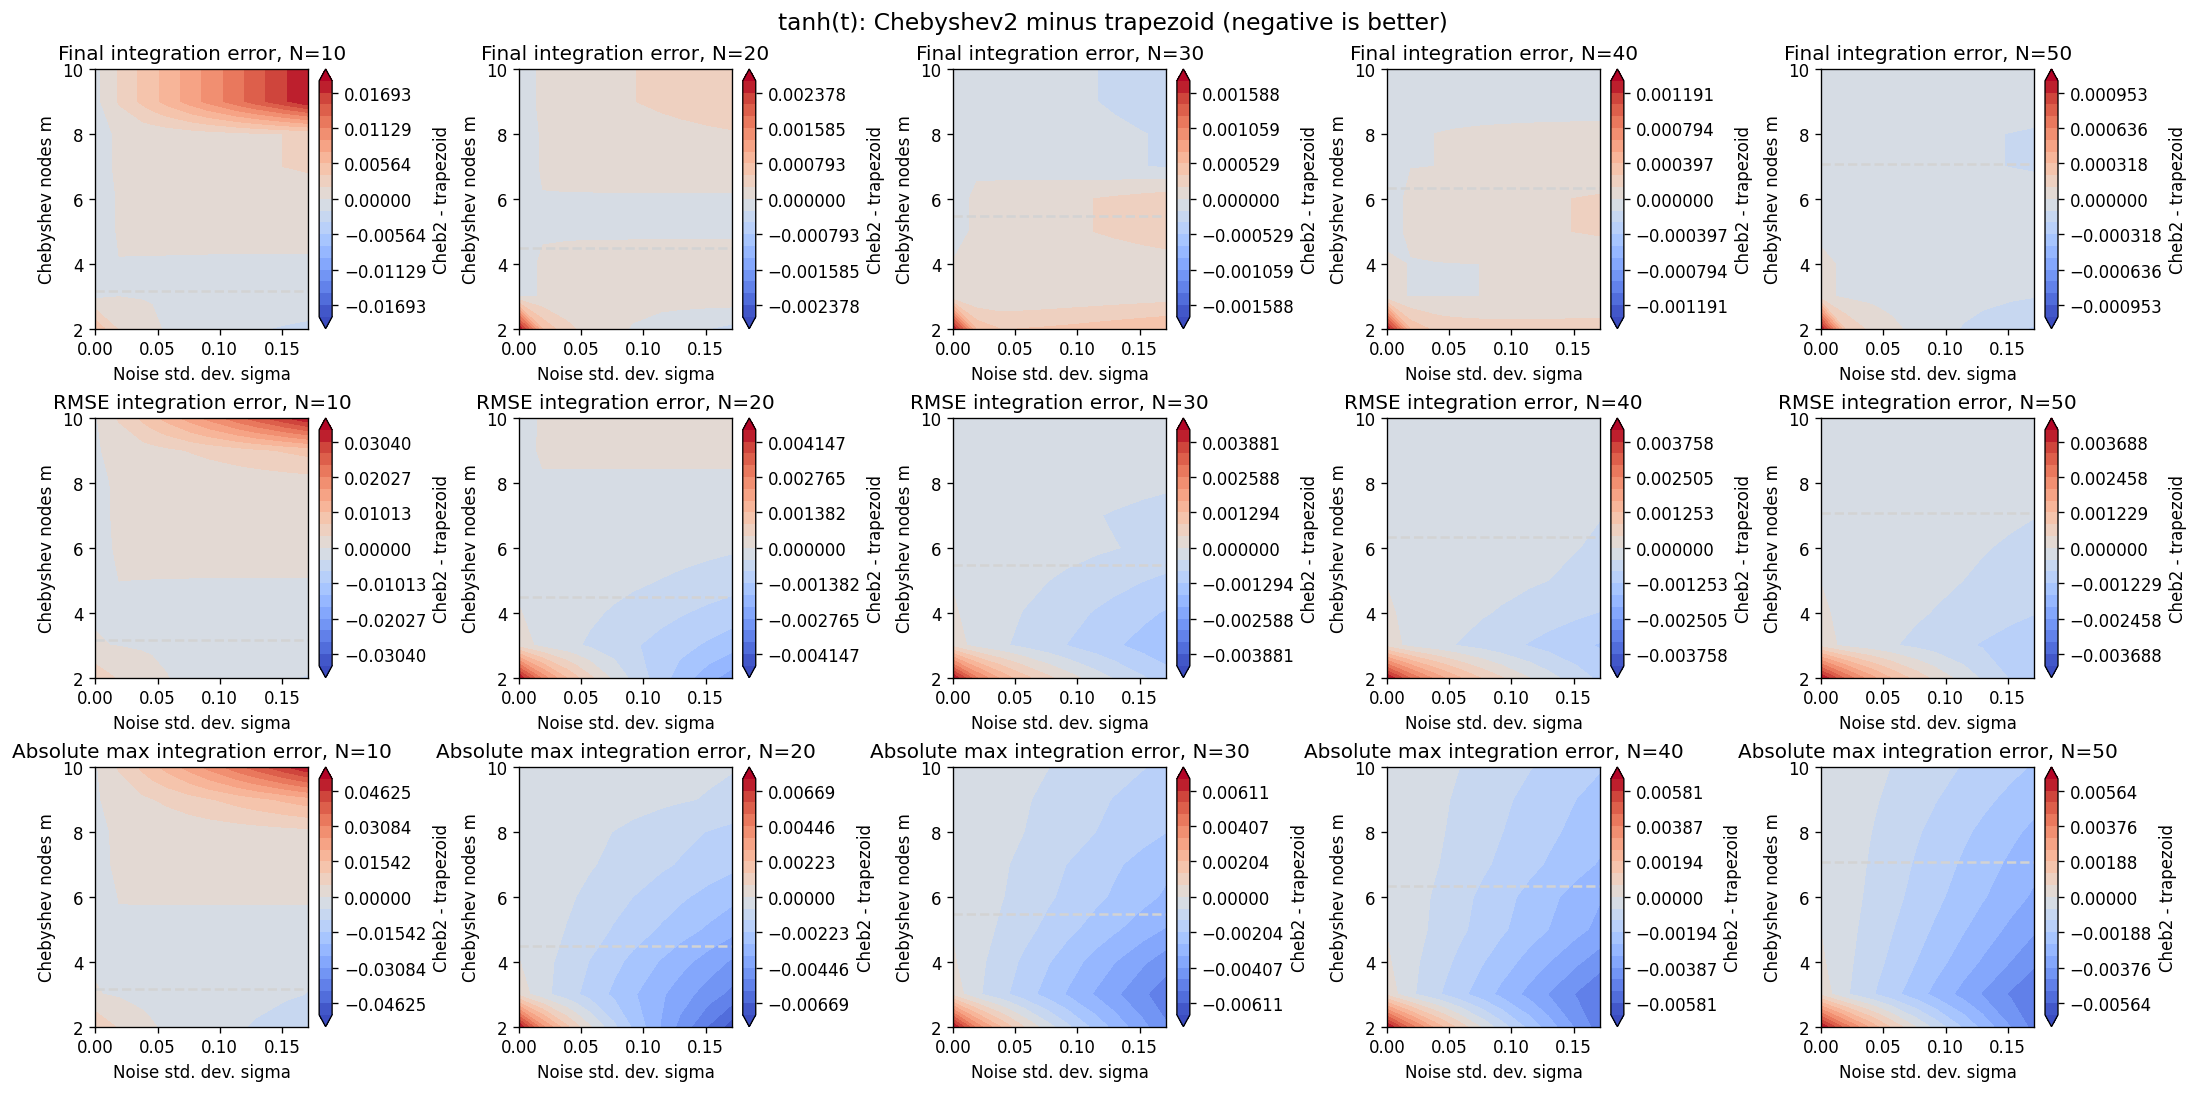

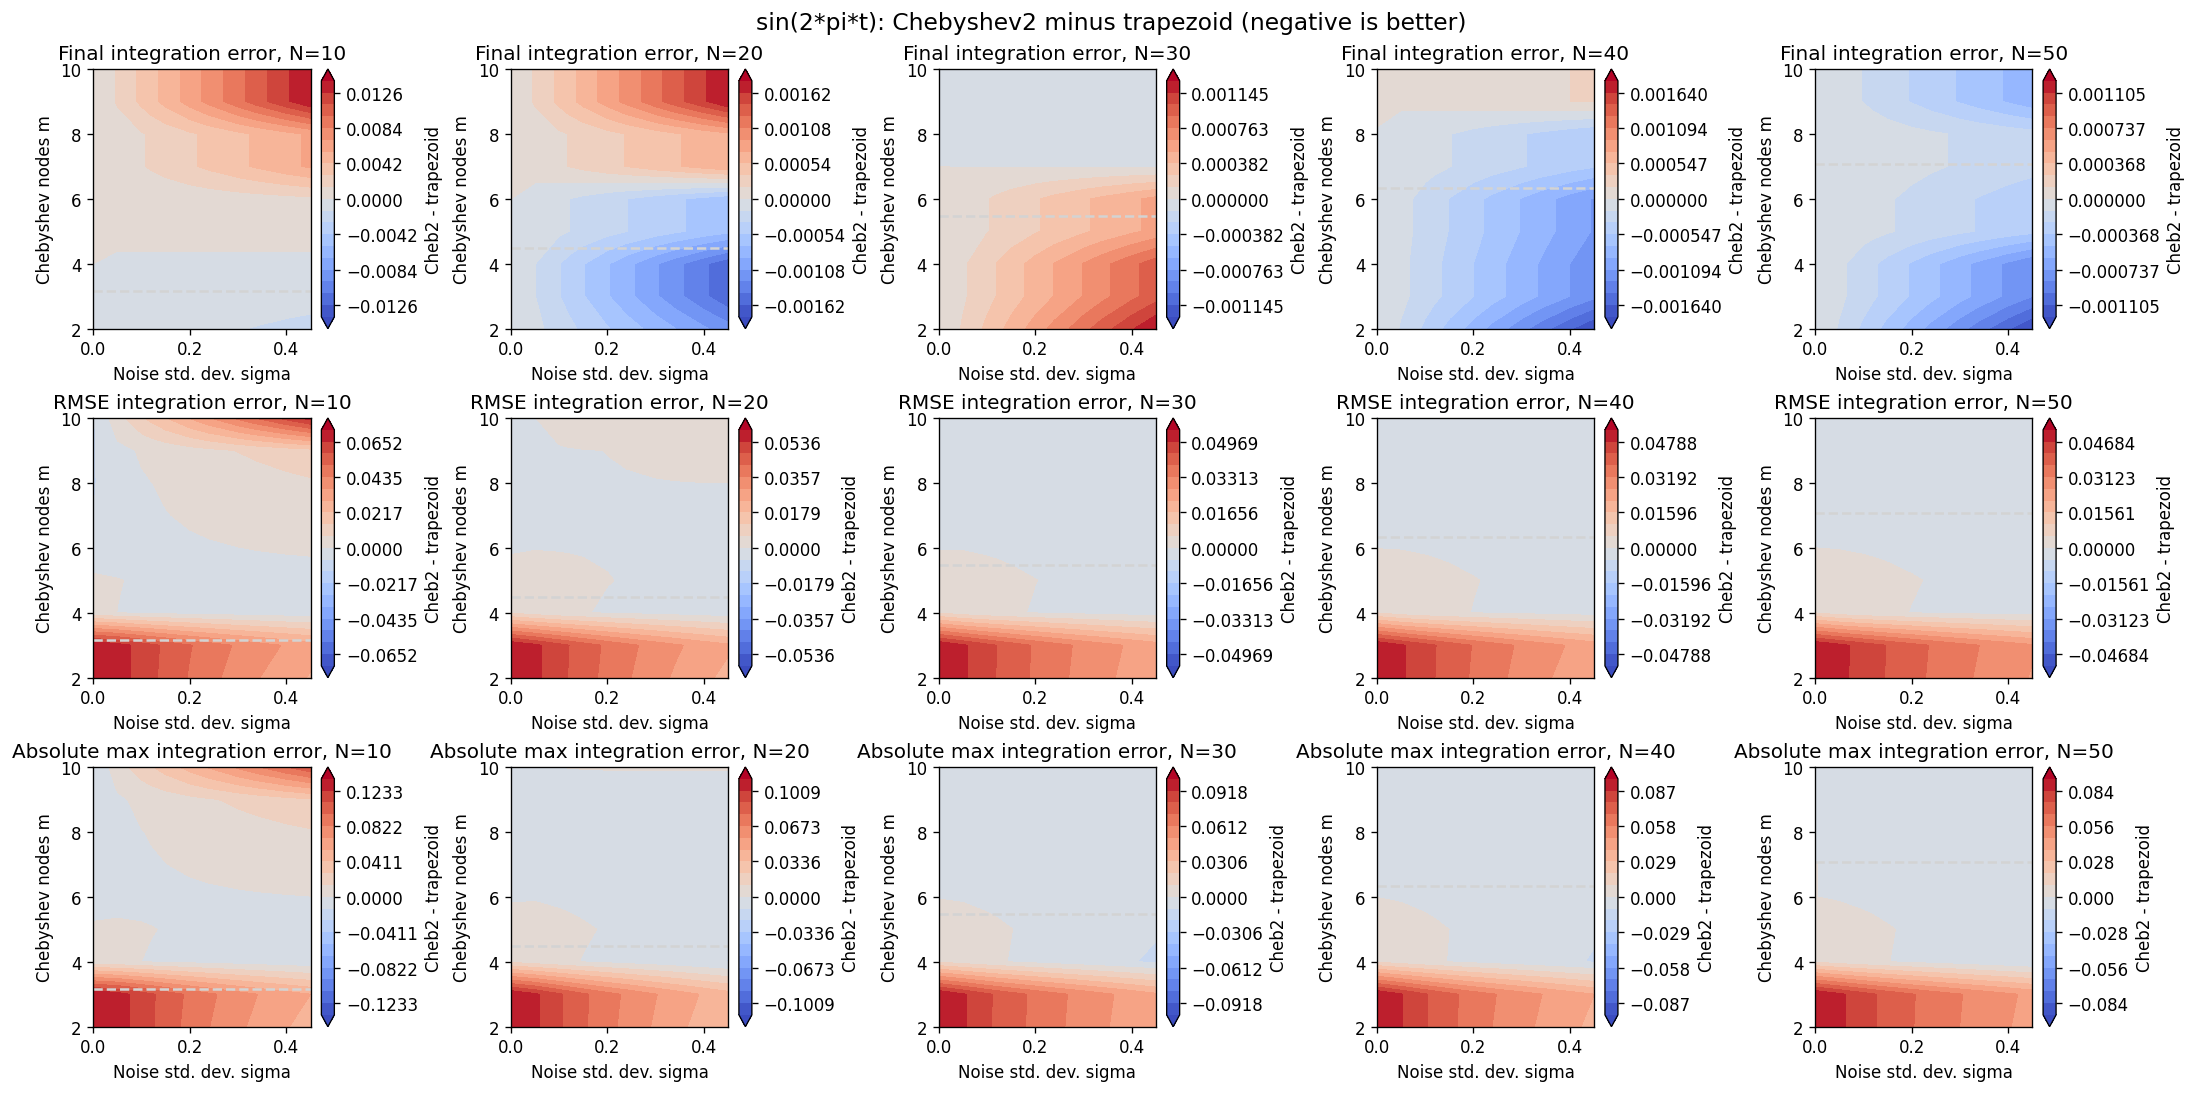

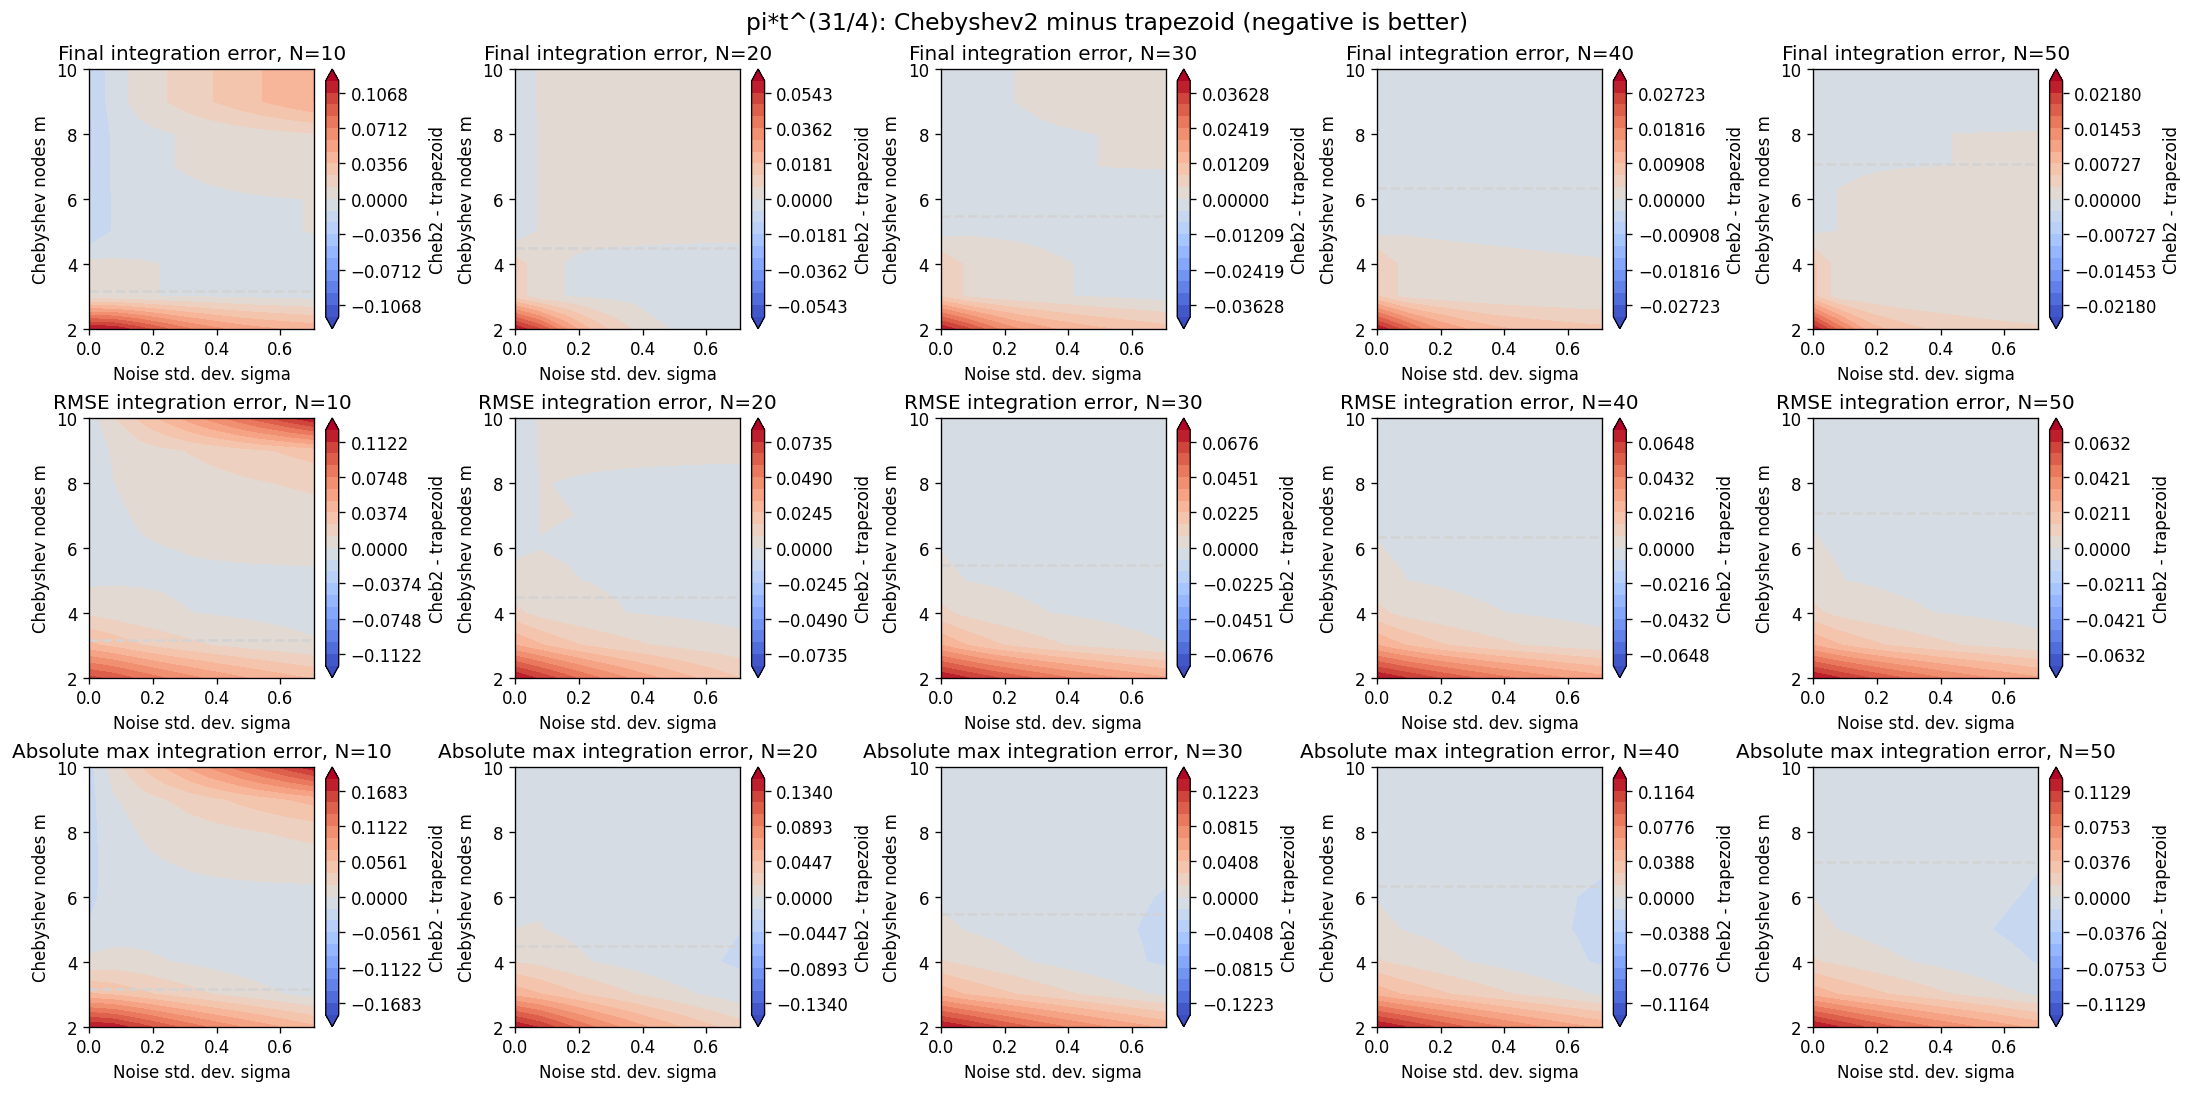

In [6]:
for function in FUNCTIONS:
    fig = plot_fixed_sample_comparison(
        comparisons,
        function_name=function.name,
        selected_sample_counts=SAMPLE_COUNTS,
        show_sqrt_sample_count=True,
    )
    display(fig)
    plt.close(fig)

In [7]:
summary = (
    comparisons.groupby(["function", "sample_count"])[["end_error", "rmse_error", "max_error"]]
    .median()
    .round(6)
)
summary

end_error  rmse_error  max_error
function    sample_count                                  
pi*t^(31/4) 10             0.000224    0.004969   0.004876
            20             0.001372    0.000192  -0.001898
            30            -0.000104   -0.000393  -0.002832
            40            -0.000292   -0.000388  -0.002932
            50             0.000040   -0.000343  -0.002879
sin(2*pi*t) 10             0.000585    0.001903   0.003787
            20            -0.000075   -0.000000  -0.000880
            30             0.000061   -0.000253  -0.001863
            40            -0.000283   -0.000258  -0.001777
            50            -0.000190   -0.000255  -0.001544
tanh(t)     10             0.000456    0.000262   0.000177
            20             0.000060   -0.000107  -0.000910
            30             0.000008   -0.000207  -0.001146
            40             0.000003   -0.000185  -0.001179
            50            -0.000027   -0.000165  -0.001293

## Decision-oriented Plotly views

These views use the same comparison dataframe as the heatmaps above. Positive advantage is `trapezoid error - Chebyshev2 error`, so values above zero favor Chebyshev2. The diamond marks the best median RMSE `m`; the light grey dashed line is `sqrt(N)`. The table reports ideal `m` by metric plus a rank-based robust `m`.

In [9]:
for function in FUNCTIONS:
    display(
        plot_advantage_curves_by_sample_count(
            comparisons,
            function.name,
            selected_sample_counts=SAMPLE_COUNTS,
            metric="rmse_error",y_range_min_m=3
        )
    )
    display(
        plot_robust_m_table(
            comparisons,
            function.name,
            selected_sample_counts=SAMPLE_COUNTS,
        )
    )